<style>
.jp-RenderedHTMLCommon,
.text_cell_render {
  font-family: medium-content-serif-font, Georgia, Cambria, "Times New Roman", Times, serif;
  font-size: 17px;
  line-height: 1.65;
  color: #1f2328;
}
.jp-RenderedHTMLCommon h1,
.jp-RenderedHTMLCommon h2,
.jp-RenderedHTMLCommon h3,
.text_cell_render h1,
.text_cell_render h2,
.text_cell_render h3 {
  font-family: sohne, "Helvetica Neue", Helvetica, Arial, sans-serif;
  color: #111;
}
.jp-RenderedHTMLCommon h1,
.text_cell_render h1 {
  font-size: 2.6rem;
  letter-spacing: -0.03em;
}
.jp-RenderedHTMLCommon h2,
.text_cell_render h2 {
  margin-top: 1.8em;
}
</style>

# Expediente D. Contrato que crece

Data Analytics | Semanas 7–8 | 2026-2

Este notebook acompaña la lectura ¿Qué puede decir realmente un contrato público?

Afirmación que se investigará:

Algunas características observables de los contratos están asociadas con la presencia posterior de registros de adición.

Este expediente utiliza dos archivos: `data/secop_recorte.csv` y `data/secop_adiciones.csv`.

Durante la primera semana se construyen tres evidencias y se documentan tres decisiones de preparación. En la segunda semana se incorpora una objeción y se revisa si la conclusión inicial se mantiene.

El objetivo es que cada cifra utilizada en la conclusión pueda localizarse en el notebook y que el alcance de la afirmación corresponda a lo que realmente muestran los datos.


**Equipo 7 · Expediente D · Distrito Capital de Bogotá · contratos firmados en 2024–2025**

Este cuaderno parte del notebook base entregado por el profesor. Se conservaron sus secciones y sus celdas preparadas; se **añadieron** las celdas que exige el Expediente D (llave de cruce, desenlace, criterio previo, comparación, objeción, potencia) y se **reordenó** un punto: el cruce con adiciones y la construcción del desenlace se hacen *antes* de documentar las decisiones de preparación, porque dos de esas decisiones nacen de ese cruce.

Cada cifra que aparece en el texto se calcula en una celda; el diccionario `R` recoge las cifras citadas en el tablero y en el veredicto.

## Preparar los datos

Ubique el notebook junto a la carpeta `data`.

```text
Expediente_D.ipynb
data/
├── secop_recorte.csv
└── secop_adiciones.csv
```

`secop_recorte.csv` contiene los contratos asignados al equipo. `secop_adiciones.csv` contiene los registros de adición asociados con esos contratos.

No es necesario descargar datos, seleccionar un equipo ni modificar filtros.


In [1]:
from pathlib import Path
from statistics import NormalDist
import json, math, re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.stats import spearmanr, chi2_contingency

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

CONTRACTS_FILE = Path("data") / "secop_recorte.csv"
ADDITIONS_FILE = Path("data") / "secop_adiciones.csv"

if not CONTRACTS_FILE.exists():
    raise FileNotFoundError("No se encontró data/secop_recorte.csv.")
if not ADDITIONS_FILE.exists():
    raise FileNotFoundError("No se encontró data/secop_adiciones.csv.")

df_raw = pd.read_csv(CONTRACTS_FILE, dtype=str)
adiciones_raw = pd.read_csv(ADDITIONS_FILE, dtype=str)

# Diccionario de cifras citadas en el tablero y el veredicto
R = {}
R["n_contratos"] = len(df_raw)
R["n_registros_adicion"] = len(adiciones_raw)

print("Contratos:", f"{len(df_raw):,}")
print("Registros de adición:", f"{len(adiciones_raw):,}")

# Metadatos de extracción (si están junto a los CSV)
for nombre in ["metadata_extraccion.json", "metadata_adiciones.json"]:
    ruta = Path("data") / nombre
    if ruta.exists():
        print()
        print(nombre)
        print(json.dumps(json.loads(ruta.read_text(encoding="utf-8")), ensure_ascii=False, indent=2))

ModuleNotFoundError: No module named 'numpy'

**Lectura de los metadatos.** `metadata_extraccion.json` indica `registros_disponibles = 567.075` contratos que cumplen el filtro (Bogotá D.C., firmados en 2024–2025) y `tope_aplicado = 50.000` con `recorte_truncado = true`: el equipo trabaja con **cerca del 8,8 %** de los contratos posibles y el criterio con que se eligieron no está documentado. `metadata_adiciones.json` indica que la tabla de adiciones se descargó **sin filtro territorial** y también con tope de 50.000 registros. Ambas cosas limitan lo que puede generalizarse y se retoman en las decisiones de preparación.

## Registro del caso

**Afirmación que investigará el equipo (brief, sección 2):**
> Existen características observables al momento de la firma que se asocian posteriormente con adiciones al contrato.

**Rol o cliente:** unidad de analítica de una firma ficticia de interventoría que quiere anticipar riesgos.

**¿Qué tendría que observar en los datos para considerar que la afirmación tiene respaldo?**
> Que, entre contratos comparables, la frecuencia o la magnitud relativa de la adición cambie de forma apreciable —según el criterio previo de abajo— con al menos una característica conocida al firmar, y que esa diferencia no desaparezca al controlar por las explicaciones alternativas más obvias (escala del contrato, modalidad, sector).

No se formula todavía ningún veredicto.

## Criterio previo del equipo (se registra antes del primer hallazgo)

**1. Cómo se medirá la adición.**

| Desenlace | Definición | Estado |
|---|---|---|
| **Principal** | `tuvo_dias_adicionados` = `dias_adicionados > 0` y `prop_dias_adicionados` = `dias_adicionados` ÷ duración pactada al firmar | Se usará |
| **Solicitado por el brief** | valor adicionado ÷ valor inicial del contrato | **No calculable**: la tabla `cb9c-h8sn` solo trae `identificador`, `id_contrato`, `tipo`, `descripcion` y `fecharegistro`; no incluye ningún monto. Se documenta como limitación y se consultará al profesor |
| **Complementario** | `tuvo_registro_adicion` = el contrato tiene al menos un registro en la tabla de adiciones | Se evalúa su cobertura antes de usarlo (sección de llave) |

La proporción se define **relativa** (días adicionados sobre duración pactada), no en valores absolutos, para atender la primera trampa del brief: los contratos grandes o largos pueden mostrar adiciones mayores por simple construcción.

**2. Características candidatas (todas conocidas al firmar).** `sector`, `modalidad_de_contratacion`, `tipo_de_contrato`, duración pactada, `valor_del_contrato` (valor inicial) y mes de firma.

**3. Qué magnitud se considerará relevante.** Con cerca de 49.000 contratos casi cualquier diferencia es «estadísticamente significativa», por lo que el criterio se fija en magnitud:
- **Variables categóricas y mes:** brecha **≥ 10 puntos porcentuales** entre el grupo con mayor y el de menor frecuencia de adición (solo grupos con al menos 100 contratos).
- **Variables numéricas:** brecha **≥ 10 puntos porcentuales** entre el primer y el cuarto cuartil, o correlación de Spearman **|ρ| ≥ 0,10**.
- Una asociación solo se considerará *robusta* si se mantiene (mismo signo y magnitud comparable) al controlar por las demás características candidatas en la segunda semana.

*Nota de trazabilidad:* los umbrales de 10 pp y 0,10 son cifras redondas fijadas por interpretabilidad. El equipo puede modificarlos; si lo hace, debe registrar el cambio antes de leer la sección de hallazgos y dejar constancia de que los resultados ya eran conocidos.

## Comprender el archivo antes de analizarlo

Cada fila de `secop_recorte.csv` representa un contrato incluido en el conjunto asignado al equipo. El archivo no corresponde a todo SECOP II, sino a una parte previamente seleccionada para la actividad.

La columna `ciudad`, cuando está disponible, identifica la ciudad de registro de la entidad que publica el contrato. No debe interpretarse automáticamente como el lugar físico donde se ejecutó el servicio, la obra o el suministro.

Las siguientes conversiones permiten trabajar con valores y fechas sin eliminar registros.


In [2]:
df = df_raw.copy()

for column in ["valor_del_contrato", "dias_adicionados"]:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

for column in [
    "fecha_de_firma",
    "fecha_de_inicio_del_contrato",
    "fecha_de_fin_del_contrato",
]:
    if column in df.columns:
        df[column] = pd.to_datetime(df[column], errors="coerce")

# Duración calculada con las fechas de inicio y fin registradas hoy en SECOP.
df["duracion_dias"] = (
    df["fecha_de_fin_del_contrato"] - df["fecha_de_inicio_del_contrato"]
).dt.days

# Duración pactada: SECOP la publica como texto ("240 Dia(s)", "6 Mes(es)"...).
def parse_duracion(texto):
    m = re.match(r"\s*(\d+)\s*(Dia|Mes|A[ñn]o|Semana|Hora)", str(texto), flags=re.I)
    if not m:
        return np.nan
    factor = {"dia": 1, "mes": 30, "año": 365, "ano": 365, "semana": 7, "hora": 1 / 24}
    return int(m.group(1)) * factor[m.group(2).lower()]

df["duracion_pactada_dias"] = df["duraci_n_del_contrato"].map(parse_duracion)

df["mes_firma"] = df["fecha_de_firma"].dt.month
df["anio_firma"] = df["fecha_de_firma"].dt.year

print("Unidades de la duración pactada:")
display(df["duraci_n_del_contrato"].str.extract(r"\d+\s*(\D+)")[0].value_counts().to_frame("contratos"))
print("Duraciones pactadas no interpretables:", int(df["duracion_pactada_dias"].isna().sum()))

sample_columns = [
    c for c in [
        "id_contrato", "nombre_entidad", "ciudad", "proveedor_adjudicado",
        "tipo_de_contrato", "modalidad_de_contratacion", "valor_del_contrato",
        "duraci_n_del_contrato", "dias_adicionados", "fecha_de_firma",
    ] if c in df.columns
]
df[sample_columns].head()

Unidades de la duración pactada:


,contratos
0,
Dia(s),29298
Mes(es),20434
Año(s),220
Semana(s),22
Hora(s),21


Duraciones pactadas no interpretables: 5


,id_contrato,nombre_entidad,ciudad,proveedor_adjudicado,tipo_de_contrato,modalidad_de_contratacion,valor_del_contrato,duraci_n_del_contrato,dias_adicionados,fecha_de_firma
0,CO1.PCCNTR.8149686,"Ministerio de las Culturas, las Artes y los Sa...",Bogotá,IMPRENTA NACIONAL DE COLOMBIA,Otro,Contratación directa,"1,399,999,500.000",240 Dia(s),180,2025-08-02
1,CO1.PCCNTR.7325911,MINISTERIO DEL INTERIOR,Bogotá,Carmen Elena Ordoñez Lasso,Prestación de servicios,Contratación directa,"104,470,000.000",337 Dia(s),0,2025-01-27
2,CO1.PCCNTR.6446468,DEFENSORÍA DEL PUEBLO,Bogotá,JULIETA BAUTISTA DUARTE,Prestación de servicios,Contratación directa,"32,838,000.000",6 Mes(es),0,2024-06-24
3,CO1.PCCNTR.8501557,SECRETARIA DE EDUCACION DEL DISTRITO,No Definido,Indira Liliana Ortiz Salas,Prestación de servicios,Contratación directa,"100,866,667.000",1 Año(s),0,2025-10-29
4,CO1.PCCNTR.6005411,IDARTES,Bogotá,jhoana maricela urquijo ramirez,Prestación de servicios,Contratación directa,"9,572,200.000",120 Dia(s),0,2024-02-27


### Antes de seguir

1. **Una fila** es un contrato electrónico publicado por una entidad estatal (`id_contrato` único en el recorte).
2. **Entidad:** `nombre_entidad`, `nit_entidad`; **proveedor:** `proveedor_adjudicado`, `documento_proveedor`.
3. **Variable monetaria:** `valor_del_contrato`; también hay columnas de pagos y saldos, que no se usan aquí.
4. **Variable que exige más cuidado:** `dias_adicionados` (solo captura ampliaciones de *tiempo*, no adiciones de *valor*) y las dos formas de medir la duración, la calculada con fechas y la pactada en texto, que la sección de decisiones compara.

## Primera semana: describir el conjunto asignado

La primera revisión se concentra en `valor_del_contrato`. Se estudiará una variable por separado antes de introducir comparaciones entre grupos.

La media, la mediana y los percentiles no responden exactamente la misma pregunta. Si la distribución contiene unos pocos contratos de valor muy alto, la media puede alejarse considerablemente de la mediana.


In [3]:
contract_value = df["valor_del_contrato"].dropna()

value_summary = pd.Series({
    "contratos con valor registrado": len(contract_value),
    "media": contract_value.mean(),
    "mediana": contract_value.median(),
    "percentil 25": contract_value.quantile(0.25),
    "percentil 75": contract_value.quantile(0.75),
    "percentil 90": contract_value.quantile(0.90),
    "mínimo": contract_value.min(),
    "máximo": contract_value.max(),
    "contratos con valor 0": int((contract_value == 0).sum()),
})

R["v_media"] = float(contract_value.mean())
R["v_mediana"] = float(contract_value.median())
R["v_max"] = float(contract_value.max())
R["v_ceros"] = int((contract_value == 0).sum())

value_summary.to_frame("resultado")

,resultado
contratos con valor registrado,"50,000.000"
media,"217,495,406.664"
mediana,"34,463,520.000"
percentil 25,"18,499,379.250"
percentil 75,"60,000,000.000"
percentil 90,"105,612,262.800"
mínimo,0.000
máximo,"770,095,956,400.000"
contratos con valor 0,488.000


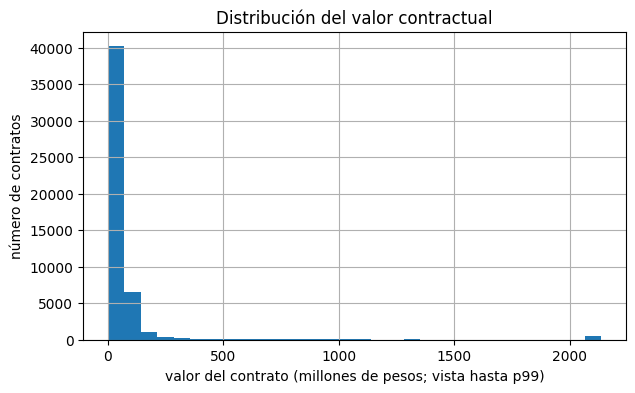

In [4]:
upper_view = contract_value.quantile(0.99)

plt.figure(figsize=(7, 4))
(contract_value.clip(upper=upper_view) / 1_000_000).hist(bins=30)
plt.xlabel("valor del contrato (millones de pesos; vista hasta p99)")
plt.ylabel("número de contratos")
plt.title("Distribución del valor contractual")
plt.show()


### Deténgase y revise

1. La **media** (217,5 millones) es muy superior a la **mediana** (34,5 millones): difieren en un orden de magnitud.
2. Para un contrato típico sirve la **mediana**; la media está arrastrada por unos pocos contratos gigantes (el máximo es de 770 mil millones de pesos).
3. El histograma muestra una distribución **muy asimétrica a la derecha**: la gran mayoría de contratos son pequeños y una cola larga concentra los valores altos.
4. Limitar la escala visual al percentil 99 solo cambia lo que se *dibuja*; los contratos por encima del p99 siguen en todas las estadísticas y en el análisis.

## Revisar la calidad antes de preparar los datos

Un faltante, un valor en cero, una repetición o un valor extremo no se elimina automáticamente. Primero debe establecerse si afecta la pregunta que se quiere responder.

La siguiente revisión muestra aspectos que pueden modificar las conclusiones.


In [5]:
quality_columns = [
    c for c in [
        "id_contrato",
        "nombre_entidad",
        "ciudad",
        "proveedor_adjudicado",
        "documento_proveedor",
        "valor_del_contrato",
        "fecha_de_inicio_del_contrato",
        "fecha_de_fin_del_contrato",
        "duracion_dias",
    ]
    if c in df.columns
]

quality = pd.DataFrame({
    "faltantes": df[quality_columns].isna().sum(),
    "porcentaje_faltante": (df[quality_columns].isna().mean() * 100).round(1),
    "valores_unicos": df[quality_columns].nunique(dropna=True),
})

display(quality)

if "id_contrato" in df.columns:
    print(
        "IDs de contrato repetidos:",
        int(df["id_contrato"].duplicated(keep=False).sum())
    )

q1, q3 = df["valor_del_contrato"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_iqr = q3 + 1.5 * iqr

print("Contratos con valor 0:", int((df["valor_del_contrato"] == 0).sum()))
print(
    "Posibles valores extremos según 1.5 × IQR:",
    int((df["valor_del_contrato"] > upper_iqr).sum())
)

if "duracion_dias" in df.columns:
    invalid_duration = (
        df["duracion_dias"].isna()
        | (df["duracion_dias"] <= 0)
    ).sum()
    print("Duraciones faltantes o no positivas:", int(invalid_duration))


,faltantes,porcentaje_faltante,valores_unicos
id_contrato,0,0.000,50000
nombre_entidad,0,0.000,358
ciudad,0,0.000,3
proveedor_adjudicado,1,0.000,44473
documento_proveedor,0,0.000,44449
valor_del_contrato,0,0.000,28216
fecha_de_inicio_del_contrato,136,0.300,760
fecha_de_fin_del_contrato,0,0.000,1295
duracion_dias,136,0.300,880


IDs de contrato repetidos: 0
Contratos con valor 0: 488
Posibles valores extremos según 1.5 × IQR: 3963
Duraciones faltantes o no positivas: 266


In [6]:
# Revisiones adicionales propias del Expediente D (no se elimina ni corrige nada)
DUR_MAX = 3650   # 10 años: umbral para señalar duraciones no verosímiles

calidad_extra = pd.Series({
    "valor_del_contrato = 0": int((df["valor_del_contrato"] == 0).sum()),
    "valor_del_contrato > 100 mil millones": int((df["valor_del_contrato"] > 1e11).sum()),
    "duración por fechas faltante o ≤ 0": int((df["duracion_dias"].isna() | (df["duracion_dias"] <= 0)).sum()),
    f"duración por fechas > {DUR_MAX} días": int((df["duracion_dias"] > DUR_MAX).sum()),
    "duración pactada faltante o < 1 día": int((df["duracion_pactada_dias"].isna() | (df["duracion_pactada_dias"] < 1)).sum()),
    f"duración pactada > {DUR_MAX} días": int((df["duracion_pactada_dias"] > DUR_MAX).sum()),
    "dias_adicionados > duración pactada": int((df["dias_adicionados"] > df["duracion_pactada_dias"]).sum()),
    "fecha de fin anterior a la de inicio": int((df["fecha_de_fin_del_contrato"] < df["fecha_de_inicio_del_contrato"]).sum()),
    "dias_adicionados faltante": int(df["dias_adicionados"].isna().sum()),
})
R["q_calidad"] = {k: int(v) for k, v in calidad_extra.items()}
R["q_ids_repetidos"] = int(df["id_contrato"].duplicated(keep=False).sum())
calidad_extra.to_frame("contratos")

,contratos
valor_del_contrato = 0,488
valor_del_contrato > 100 mil millones,12
duración por fechas faltante o ≤ 0,266
duración por fechas > 3650 días,14
duración pactada faltante o < 1 día,21
duración pactada > 3650 días,69
dias_adicionados > duración pactada,1299
fecha de fin anterior a la de inicio,5
dias_adicionados faltante,0


### Comprobar si una decisión cambia el resultado

Antes de decidir qué hacer con los valores en cero o con los contratos más altos, conviene observar cuánto cambia una estadística sencilla.

La siguiente comparación no prescribe una limpieza. Su función es mostrar si la mediana resulta sensible a tres formas distintas de preparar el valor contractual.


In [7]:
medians = {}

all_values = df["valor_del_contrato"].dropna()
if len(all_values):
    medians["sin retirar ceros"] = all_values.median()

positive_values = df.loc[
    df["valor_del_contrato"] > 0,
    "valor_del_contrato"
].dropna()

if len(positive_values):
    medians["solo valores positivos"] = positive_values.median()

if len(positive_values):
    p99 = positive_values.quantile(0.99)
    below_p99 = positive_values[positive_values <= p99]
    medians["positivos, sin el 1 % superior"] = below_p99.median()

pd.Series(medians, name="mediana_valor")


sin retirar ceros                34,463,520.000
solo valores positivos           34,925,987.500
positivos, sin el 1 % superior   34,461,348.350
Name: mediana_valor, dtype: float64

**Lectura de la calidad.** El `id_contrato` es único (sin duplicados). Hay contratos con valor 0, valores por encima de los 100 mil millones de pesos, fechas de fin anteriores al inicio y años de fin absurdos (hasta 2205). La mediana del valor casi no cambia entre las tres preparaciones (ver tabla), pero el valor máximo distorsiona cualquier media; por eso el análisis trabaja con cuartiles, medianas y correlaciones por rangos.

## Relacionar contratos y adiciones: construcción y verificación de la llave

La segunda trampa del brief es de cruce: una llave mal construida puede **crear** adiciones inexistentes o **perder** adiciones reales. Antes de usar `tuvo_adicion` como desenlace se verifican cuatro cosas: (1) que la llave tenga el mismo formato en ambas tablas, (2) que el cruce no multiplique filas de contratos, (3) qué parte del recorte encuentra pareja, y (4) si los registros que empatan son coherentes en el tiempo.

**Llave elegida:** `id_contrato` (formato `CO1.PCCNTR.<número>`). La tabla de adiciones trae además `identificador` (`CO1.CTRMOD.<número>`), que identifica la *modificación*, no el contrato, y por eso se usa solo para contar modificaciones distintas.

In [8]:
ad = adiciones_raw.copy()
ad["fecharegistro"] = pd.to_datetime(ad["fecharegistro"], errors="coerce")

# (1) Formato de la llave y efecto de normalizarla
patron = r"^CO1\.PCCNTR\.\d+$"
R["k_formato_contratos"] = float(df["id_contrato"].str.match(patron).mean())
R["k_formato_adiciones"] = float(ad["id_contrato"].str.match(patron).mean())

llave_c = df["id_contrato"].str.strip().str.upper()
llave_a = ad["id_contrato"].str.strip().str.upper()
R["k_match_directo"] = int(df["id_contrato"].isin(ad["id_contrato"]).sum())
R["k_match_normalizado"] = int(llave_c.isin(llave_a).sum())

print("Formato CO1.PCCNTR.<n> — contratos:", f"{R['k_formato_contratos']:.1%}", "| adiciones:", f"{R['k_formato_adiciones']:.1%}")
print("Contratos con pareja, llave directa    :", R["k_match_directo"])
print("Contratos con pareja, llave normalizada:", R["k_match_normalizado"], "(strip + mayúsculas: no cambia nada)")

# (2) Cardinalidad: un contrato puede tener varios registros de adición
print()
print("id_contrato único en el recorte:", df["id_contrato"].is_unique)
R["k_registros_duplicados_exactos"] = int(ad.duplicated().sum())
R["k_identificadores_unicos"] = int(ad["identificador"].nunique())
R["k_contratos_en_adiciones"] = int(ad["id_contrato"].nunique())
por_contrato = ad.groupby("id_contrato")["identificador"].nunique()
R["k_max_modificaciones_por_contrato"] = int(por_contrato.max())
print("Filas de adiciones:", len(ad), "| filas exactamente repetidas:", R["k_registros_duplicados_exactos"],
      "| identificadores únicos:", R["k_identificadores_unicos"])
print("Contratos distintos en la tabla de adiciones:", R["k_contratos_en_adiciones"])
print("Máximo de modificaciones por contrato en toda la tabla:", R["k_max_modificaciones_por_contrato"])

naive = df.merge(ad, on="id_contrato", how="left")
R["k_filas_cruce_ingenuo"] = len(naive)
print()
print("Filas tras un cruce directo (sin agregar):", len(naive), "vs. contratos:", len(df))
print("→ Aquí no se inflan filas porque los pocos contratos que empatan tienen un solo registro;",
      "aun así se agrega por contrato para que el procedimiento sea seguro.")

por_contrato_df = (
    ad.groupby("id_contrato")
      .agg(numero_registros_adicion=("identificador", "nunique"),
           primera_fecha_registro=("fecharegistro", "min"))
      .reset_index()
)
df = df.merge(por_contrato_df, on="id_contrato", how="left")
df["numero_registros_adicion"] = df["numero_registros_adicion"].fillna(0).astype(int)
df["tuvo_registro_adicion"] = df["numero_registros_adicion"] > 0
assert len(df) == R["n_contratos"], "El cruce cambió el número de contratos"

# (3) Cobertura
R["k_contratos_con_registro"] = int(df["tuvo_registro_adicion"].sum())
R["k_pct_contratos_con_registro"] = float(df["tuvo_registro_adicion"].mean())
R["k_registros_fuera_recorte"] = int((~ad["id_contrato"].isin(df["id_contrato"])).sum())
R["k_fecha_min_registro"] = str(ad["fecharegistro"].min().date())
R["k_fecha_max_registro"] = str(ad["fecharegistro"].max().date())
ventana = df["fecha_de_firma"] <= ad["fecharegistro"].max()
R["k_firmados_en_ventana"] = int(ventana.sum())
R["k_pct_con_registro_en_ventana"] = float(df.loc[ventana, "tuvo_registro_adicion"].mean())

print()
print("Contratos del recorte con al menos un registro de adición:", R["k_contratos_con_registro"],
      f"({R['k_pct_contratos_con_registro']:.2%})")
print("Registros de adición que NO pertenecen a ningún contrato del recorte:", R["k_registros_fuera_recorte"],
      f"({R['k_registros_fuera_recorte'] / len(ad):.1%})")
print("Rango de fecharegistro en la tabla de adiciones:", R["k_fecha_min_registro"], "→", R["k_fecha_max_registro"])
print("Contratos firmados hasta la última fecha de la tabla:", R["k_firmados_en_ventana"],
      f"| con registro: {R['k_pct_con_registro_en_ventana']:.2%}")

# (4) Coherencia temporal de los pares que sí empatan
pares = df.loc[df["tuvo_registro_adicion"], ["id_contrato", "fecha_de_firma", "primera_fecha_registro"]]
R["k_registro_antes_de_firma"] = int((pares["primera_fecha_registro"] < pares["fecha_de_firma"]).sum())
R["k_pares"] = len(pares)
print()
print("Pares con registro de adición ANTERIOR a la fecha de firma:", R["k_registro_antes_de_firma"], "de", R["k_pares"])

tipos_empatados = ad.loc[ad["id_contrato"].isin(df["id_contrato"]), "tipo"].value_counts()
R["k_tipos_empatados"] = tipos_empatados.to_dict()
display(tipos_empatados.to_frame("registros"))
print("Columnas de la tabla de adiciones:", list(ad.columns))

Formato CO1.PCCNTR.<n> — contratos: 100.0% | adiciones: 100.0%
Contratos con pareja, llave directa    : 114
Contratos con pareja, llave normalizada: 114 (strip + mayúsculas: no cambia nada)

id_contrato único en el recorte: True


Filas de adiciones: 50000 | filas exactamente repetidas: 78 | identificadores únicos: 49912
Contratos distintos en la tabla de adiciones: 48705
Máximo de modificaciones por contrato en toda la tabla: 4

Filas tras un cruce directo (sin agregar): 50000 vs. contratos: 50000
→ Aquí no se inflan filas porque los pocos contratos que empatan tienen un solo registro; aun así se agrega por contrato para que el procedimiento sea seguro.



Contratos del recorte con al menos un registro de adición: 114 (0.23%)
Registros de adición que NO pertenecen a ningún contrato del recorte: 49886 (99.8%)
Rango de fecharegistro en la tabla de adiciones: 2016-01-01 → 2024-09-09
Contratos firmados hasta la última fecha de la tabla: 19027 | con registro: 0.58%

Pares con registro de adición ANTERIOR a la fecha de firma: 17 de 114


,registros
tipo,
MODIFICACION GENERAL,97
No definido,7
CESION,4
REACTIVACIoN,3
SUSPENSIoN,2
ADICION EN EL VALOR,1


Columnas de la tabla de adiciones: ['identificador', 'id_contrato', 'tipo', 'descripcion', 'fecharegistro']


**Qué muestra la verificación.** La llave `id_contrato` tiene el mismo formato en ambas tablas y normalizarla no cambia el resultado, así que el problema **no** es de formato. El problema es de **cobertura**: la tabla de adiciones se descargó sin filtro territorial, con tope de 50.000 filas. Por su rango de fechas (de 2016 a septiembre de 2024) todo indica que la descarga se cortó al llegar al tope, probablemente ordenada por fecha de registro: solo llega hasta el 9 de septiembre de 2024 y casi todos sus registros pertenecen a contratos de otros departamentos o de años anteriores. Por eso solo una fracción diminuta del recorte encuentra pareja (ver la salida).

## Construcción del desenlace y comparación de las tres formas de medirlo

Se crean los tres indicadores declarados en el criterio previo y se comparan entre sí. Si el registro en la tabla de adiciones fuera un buen desenlace, coincidiría en gran medida con `dias_adicionados > 0`.

In [9]:
DUR_MAX = 3650
df["duracion_pactada_valida"] = df["duracion_pactada_dias"].where(
    df["duracion_pactada_dias"].between(1, DUR_MAX)
)

df["tuvo_dias_adicionados"] = df["dias_adicionados"].fillna(0) > 0
df["prop_dias_adicionados"] = df["dias_adicionados"] / df["duracion_pactada_valida"]
df["es_modificado"] = df["estado_contrato"].eq("Modificado")

cruce_desenlaces = pd.crosstab(
    df["tuvo_dias_adicionados"].map({True: "con días adicionados", False: "sin días adicionados"}),
    df["tuvo_registro_adicion"].map({True: "con registro en tabla de adiciones", False: "sin registro en tabla de adiciones"}),
    margins=True,
)
display(cruce_desenlaces)

R["o_n_dias"] = int(df["tuvo_dias_adicionados"].sum())
R["o_pct_dias"] = float(df["tuvo_dias_adicionados"].mean())
R["o_dias_con_registro"] = int((df["tuvo_dias_adicionados"] & df["tuvo_registro_adicion"]).sum())
R["o_dias_sin_registro"] = int((df["tuvo_dias_adicionados"] & ~df["tuvo_registro_adicion"]).sum())
R["o_registro_sin_dias"] = int((~df["tuvo_dias_adicionados"] & df["tuvo_registro_adicion"]).sum())
R["o_pct_dias_cubiertos_por_tabla"] = R["o_dias_con_registro"] / R["o_n_dias"]

print(f"Contratos con días adicionados: {R['o_n_dias']:,} ({R['o_pct_dias']:.1%})")
print(f"…de ellos, con registro en la tabla de adiciones: {R['o_dias_con_registro']} ({R['o_pct_dias_cubiertos_por_tabla']:.2%})")
print(f"…de ellos, SIN registro en la tabla (adiciones reales que el cruce pierde): {R['o_dias_sin_registro']:,}")

# Otro indicador de contrato modificado: el estado publicado en SECOP
cruce_estado = pd.crosstab(
    df["estado_contrato"].eq("Modificado").map({True: "estado = Modificado", False: "otro estado"}),
    df["tuvo_dias_adicionados"].map({True: "con días adicionados", False: "sin días adicionados"}),
    margins=True,
)
display(cruce_estado)
R["o_modificado"] = int(df["es_modificado"].sum())
R["o_modificado_y_dias"] = int((df["es_modificado"] & df["tuvo_dias_adicionados"]).sum())
R["o_modificado_sin_dias"] = int((df["es_modificado"] & ~df["tuvo_dias_adicionados"]).sum())
R["o_dias_no_modificado"] = int((~df["es_modificado"] & df["tuvo_dias_adicionados"]).sum())

tuvo_registro_adicion,con registro en tabla de adiciones,sin registro en tabla de adiciones,All
tuvo_dias_adicionados,,,
con días adicionados,46,13279,13325
sin días adicionados,68,36607,36675
All,114,49886,50000


Contratos con días adicionados: 13,325 (26.7%)
…de ellos, con registro en la tabla de adiciones: 46 (0.35%)
…de ellos, SIN registro en la tabla (adiciones reales que el cruce pierde): 13,279


tuvo_dias_adicionados,con días adicionados,sin días adicionados,All
estado_contrato,,,
estado = Modificado,12204,3473,15677
otro estado,1121,33202,34323
All,13325,36675,50000


**Lectura.** De los 13.325 contratos con días adicionados, solo 46 (0,35 %) aparecen en la tabla de adiciones; usarla como desenlace clasificaría a los otros 13.279 como «sin adición». Por el contrario, el estado `Modificado` sí coincide con los días adicionados en 12.204 contratos (de 15.677 modificados); los 3.473 restantes fueron modificados por otra vía (posiblemente valor u otras condiciones), pero el estado no dice de qué tipo. Esto respalda usar `dias_adicionados` como desenlace principal y `es_modificado` como contraste de robustez.

### Tres decisiones de preparación

Decisiones del equipo. Cada una responde:

1. ¿Qué situación encontró?
2. ¿Qué tratamiento decidió aplicar?
3. ¿Qué salida del notebook respalda la decisión?
4. ¿Qué podría cambiar en la conclusión si la decisión fuera equivocada?

No es necesario que todos los equipos adopten las mismas decisiones.


### Evidencia de la decisión 2: ¿la duración por fechas es realmente conocida al firmar?

Si las fechas de inicio y fin se actualizan cuando el contrato se prorroga, la duración calculada con fechas *ya contiene* los días adicionados y no puede usarse como característica «observable al firmar». La comparación con la duración pactada en texto permite comprobarlo.

In [10]:
v = df[(df["duracion_dias"] > 0) & (df["duracion_pactada_valida"] > 0)].copy()
v["diferencia_fechas_menos_pactada"] = v["duracion_dias"] - v["duracion_pactada_valida"]

tabla_dif = (
    v.groupby("tuvo_dias_adicionados")["diferencia_fechas_menos_pactada"]
     .describe(percentiles=[0.25, 0.5, 0.75])[["count", "25%", "50%", "75%"]]
     .rename(index={False: "sin días adicionados", True: "con días adicionados"})
)
display(tabla_dif)

R["d2_mediana_dif_sin"] = float(v.loc[~v["tuvo_dias_adicionados"], "diferencia_fechas_menos_pactada"].median())
R["d2_mediana_dif_con"] = float(v.loc[v["tuvo_dias_adicionados"], "diferencia_fechas_menos_pactada"].median())
R["d2_concordancia_sin"] = float((v.loc[~v["tuvo_dias_adicionados"], "diferencia_fechas_menos_pactada"].abs() <= 31).mean())

rho_fechas = spearmanr(v["duracion_dias"], v["tuvo_dias_adicionados"].astype(int))[0]
rho_pactada = spearmanr(v["duracion_pactada_valida"], v["tuvo_dias_adicionados"].astype(int))[0]
R["d2_rho_fechas"] = float(rho_fechas)
R["d2_rho_pactada"] = float(rho_pactada)

tasa_por_cuartil = pd.DataFrame({
    "duración por fechas": v.groupby(pd.qcut(v["duracion_dias"], 4, labels=["C1", "C2", "C3", "C4"]), observed=True)["tuvo_dias_adicionados"].mean(),
    "duración pactada": v.groupby(pd.qcut(v["duracion_pactada_valida"], 4, labels=["C1", "C2", "C3", "C4"], duplicates="drop"), observed=True)["tuvo_dias_adicionados"].mean(),
})
display((tasa_por_cuartil * 100).round(1).rename_axis("cuartil de duración").add_suffix(" (% con días adicionados)"))
R["d2_tasa_fechas_c1"] = float(tasa_por_cuartil["duración por fechas"].iloc[0])
R["d2_tasa_fechas_c4"] = float(tasa_por_cuartil["duración por fechas"].iloc[-1])
R["d2_tasa_pactada_c1"] = float(tasa_por_cuartil["duración pactada"].iloc[0])
R["d2_tasa_pactada_c4"] = float(tasa_por_cuartil["duración pactada"].iloc[-1])
print(f"Spearman (duración por fechas ↔ días adicionados): {rho_fechas:.3f}")
print(f"Spearman (duración pactada    ↔ días adicionados): {rho_pactada:.3f}")

,count,25%,50%,75%
tuvo_dias_adicionados,,,,
sin días adicionados,"36,367.000",-4.000,0.000,3.000
con días adicionados,"13,286.000",2.000,8.000,90.000


,duración por fechas (% con días adicionados),duración pactada (% con días adicionados)
cuartil de duración,,
C1,12.800,26.800
C2,19.700,21.900
C3,31.500,27.300
C4,43.200,32.700


Spearman (duración por fechas ↔ días adicionados): 0.278
Spearman (duración pactada    ↔ días adicionados): 0.051


### Decisión 1 — La tabla de adiciones no se usa como desenlace principal

- **Situación encontrada:** la llave `id_contrato` es válida y el cruce no altera el número de contratos, pero solo 114 de 50.000 contratos (0,23 %) tienen algún registro de adición. La tabla llega hasta 2024-09-09 (los contratos firmados después de esa fecha no pueden tener registro en esta descarga), no filtra por territorio (49.886 de 50.000 registros no pertenecen al recorte) y no trae montos. Además, 17 de los 114 pares tienen un registro con fecha anterior a la firma del contrato, lo que sugiere inconsistencias entre tablas.
- **Decisión:** el desenlace principal es `dias_adicionados > 0` y su proporción sobre la duración pactada. La tabla de adiciones se conserva como fuente complementaria (`tuvo_registro_adicion`) y como contraste de robustez, no como desenlace.
- **Evidencia:** celdas de llave y de desenlace. De 13.325 contratos con días adicionados solo 46 tienen registro en la tabla; el cruce «perdería» 13.279 adiciones reales.
- **Qué podría cambiar si fuera equivocada:** si se hubiera usado la tabla como desenlace, la tasa de adición sería 0,23 % en lugar de 26,7 % y las diferencias entre grupos reflejarían qué contratos alcanzaron a quedar en la descarga, no cuáles fueron adicionados. Como no se puede calcular el valor adicionado, la conclusión se limita a **ampliaciones de tiempo**, no a adiciones presupuestales.

### Decisión 2 — La duración se mide con la duración pactada (texto), no con las fechas de fin

- **Situación encontrada:** la duración calculada con `fecha_de_fin − fecha_de_inicio` difiere de la duración pactada en una mediana de 8 días en contratos con días adicionados frente a 0 días en los que no los tienen: las fechas de fin parecen actualizarse con las prórrogas.
- **Decisión:** como característica «observable al firmar» se usa `duracion_pactada_dias` (columna `duraci_n_del_contrato`). La duración por fechas se conserva solo para mostrar la sensibilidad.
- **Evidencia:** en la celda de arriba, con la duración por fechas el porcentaje de contratos con días adicionados pasa de 12,8 % en el primer cuartil a 43,2 % en el cuarto (ρ = 0,28); con la duración pactada pasa de 26,8 % a 32,7 % (ρ = 0,05).
- **Qué podría cambiar si fuera equivocada:** con la duración por fechas la conclusión sería que «los contratos largos se adicionan mucho más», efecto en buena parte mecánico. Aun así, la duración pactada no está verificada como inmodificable (el recorte no incluye la versión original del contrato); es la mejor aproximación disponible y debe reportarse como tal.

### Decisión 3 — Se excluyen del análisis comparativo los contratos con valor 0 o con duración pactada no interpretable; los valores extremos se conservan

- **Situación encontrada:** 488 contratos con valor 0 (no admiten proporción ni cuartil de valor con sentido), 21 con duración pactada faltante o menor a un día y 69 con duración pactada superior a 10 años. También hay valores de hasta 770 mil millones de pesos.
- **Decisión:** `df_analisis` retiene los contratos con `valor_del_contrato > 0` y duración pactada entre 1 y 3.650 días. Los valores extremos **no** se eliminan: el análisis usa cuartiles, medianas, correlaciones por rangos y logaritmos, que los toleran, y se verifica la sensibilidad sin el 1 % superior.
- **Evidencia:** tablas de calidad y celda de sensibilidad de la segunda semana.
- **Qué podría cambiar si fuera equivocada:** si los ceros correspondieran a convenios con aportes no monetarios y tuvieran más adiciones, la exclusión subestimaría la asociación con el valor bajo; la proporción de contratos afectados es pequeña, por lo que el cambio esperado también lo es.

In [11]:
df_analisis = df[
    (df["valor_del_contrato"] > 0) & df["duracion_pactada_valida"].notna()
].copy()

df_analisis["cuartil_valor"] = pd.qcut(df_analisis["valor_del_contrato"], 4, labels=["Q1", "Q2", "Q3", "Q4"])
df_analisis["cuartil_duracion"] = pd.qcut(df_analisis["duracion_pactada_valida"], 4, labels=["D1", "D2", "D3", "D4"])

R["a_n"] = len(df_analisis)
R["a_excluidos"] = len(df) - len(df_analisis)
R["a_pct_dias"] = float(df_analisis["tuvo_dias_adicionados"].mean())

print(f"Datos originales: {len(df):,}")
print(f"Datos para análisis (df_analisis): {len(df_analisis):,}  (excluidos: {R['a_excluidos']:,})")
print(f"Contratos con días adicionados en df_analisis: {R['a_pct_dias']:.1%}")

display(df_analisis.groupby("cuartil_valor", observed=True)["valor_del_contrato"].agg(["min", "max"]).rename_axis("cuartil de valor"))
display(df_analisis.groupby("cuartil_duracion", observed=True)["duracion_pactada_valida"].agg(["min", "max"]).rename_axis("cuartil de duración pactada"))

Datos originales: 50,000
Datos para análisis (df_analisis): 49,432  (excluidos: 568)
Contratos con días adicionados en df_analisis: 26.8%


,min,max
cuartil de valor,,
Q1,0.010,"18,992,000.000"
Q2,"18,992,198.000","34,924,480.000"
Q3,"34,924,669.000","60,203,000.000"
Q4,"60,207,354.000","770,095,956,400.000"


,min,max
cuartil de duración pactada,,
D1,1.000,99.000
D2,100.000,180.000
D3,181.000,297.000
D4,298.000,"3,650.000"


## Expediente D: proporción de adición y comparación entre contratos con y sin adición

Primero se caracteriza la distribución de la proporción `prop_dias_adicionados` (días adicionados ÷ duración pactada). Después se compara la frecuencia de días adicionados entre grupos definidos por las características candidatas, con intervalos de confianza de Wilson al 95 % y contra los umbrales del criterio previo.

In [12]:
prop = df_analisis["prop_dias_adicionados"]
prop_pos = prop[prop > 0]

R["e1_tasa"] = float(df_analisis["tuvo_dias_adicionados"].mean())
R["e1_n_con"] = int(df_analisis["tuvo_dias_adicionados"].sum())
R["e1_share_cero"] = float((prop == 0).mean())
R["e1_mediana_pos"] = float(prop_pos.median())
R["e1_p75_pos"] = float(prop_pos.quantile(0.75))
R["e1_p90_pos"] = float(prop_pos.quantile(0.90))
R["e1_share_mayor_1"] = float((prop_pos > 1).mean())
R["e1_n_mayor_1"] = int((prop_pos > 1).sum())
R["e1_mediana_dias_pos"] = float(df_analisis.loc[df_analisis["tuvo_dias_adicionados"], "dias_adicionados"].median())

resumen_prop = pd.Series({
    "contratos analizados": len(prop),
    "con días adicionados": R["e1_n_con"],
    "% con días adicionados": R["e1_tasa"] * 100,
    "% con proporción = 0": R["e1_share_cero"] * 100,
    "mediana de la proporción (solo con adición)": R["e1_mediana_pos"],
    "percentil 75 (solo con adición)": R["e1_p75_pos"],
    "percentil 90 (solo con adición)": R["e1_p90_pos"],
    "contratos con proporción > 1 (adición mayor a la duración pactada)": R["e1_n_mayor_1"],
    "mediana de días adicionados (solo con adición)": R["e1_mediana_dias_pos"],
})
display(resumen_prop.to_frame("resultado"))

,resultado
contratos analizados,"49,432.000"
con días adicionados,"13,253.000"
% con días adicionados,26.811
% con proporción = 0,73.189
mediana de la proporción (solo con adición),0.290
percentil 75 (solo con adición),0.498
percentil 90 (solo con adición),1.000
contratos con proporción > 1 (adición mayor a la duración pactada),"1,295.000"
mediana de días adicionados (solo con adición),46.000


In [13]:
# Comparación con las características candidatas declaradas en el criterio previo
UMBRAL_BRECHA_PP = 10.0
UMBRAL_RHO = 0.10
MIN_N = 100
y = "tuvo_dias_adicionados"


def wilson(k, n, z=1.96):
    k = np.asarray(k, dtype=float)
    n = np.asarray(n, dtype=float)
    p = k / n
    d = 1 + z**2 / n
    centro = (p + z**2 / (2 * n)) / d
    margen = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / d
    return centro - margen, centro + margen


def tasas_por_grupo(variable):
    g = df_analisis.groupby(variable, observed=True)[y].agg(n="size", con_adicion="sum", tasa="mean")
    g["ic95_inf"], g["ic95_sup"] = wilson(g["con_adicion"], g["n"])
    return g


def cramer_v(variable):
    frecuentes = df_analisis[variable].map(df_analisis[variable].value_counts()) >= MIN_N
    tabla = pd.crosstab(df_analisis.loc[frecuentes, variable], df_analisis.loc[frecuentes, y])
    return math.sqrt(chi2_contingency(tabla)[0] / tabla.values.sum())


filas = []
tablas = {}
for variable in ["sector", "modalidad_de_contratacion", "tipo_de_contrato", "mes_firma"]:
    g = tasas_por_grupo(variable)
    tablas[variable] = g
    g = g[g["n"] >= MIN_N]
    filas.append({
        "característica": variable,
        "grupos (n ≥ 100)": len(g),
        "grupo con menor tasa": str(g["tasa"].idxmin()),
        "tasa mínima %": g["tasa"].min() * 100,
        "grupo con mayor tasa": str(g["tasa"].idxmax()),
        "tasa máxima %": g["tasa"].max() * 100,
        "brecha (pp)": (g["tasa"].max() - g["tasa"].min()) * 100,
        "V de Cramér": cramer_v(variable),
        "ρ Spearman": np.nan,
    })

for variable, cuartil in [("valor_del_contrato", "cuartil_valor"), ("duracion_pactada_valida", "cuartil_duracion")]:
    g = tasas_por_grupo(cuartil)
    tablas[variable] = g
    filas.append({
        "característica": variable,
        "grupos (n ≥ 100)": 4,
        "grupo con menor tasa": str(g["tasa"].idxmin()),
        "tasa mínima %": g["tasa"].min() * 100,
        "grupo con mayor tasa": str(g["tasa"].idxmax()),
        "tasa máxima %": g["tasa"].max() * 100,
        "brecha (pp)": (g["tasa"].iloc[-1] - g["tasa"].iloc[0]) * 100,   # Q4 - Q1
        "V de Cramér": np.nan,
        "ρ Spearman": spearmanr(df_analisis[variable], df_analisis[y].astype(int))[0],
    })

comparacion = pd.DataFrame(filas).set_index("característica")
comparacion["¿supera el umbral?"] = (
    (comparacion["brecha (pp)"].abs() >= UMBRAL_BRECHA_PP)
    | (comparacion["ρ Spearman"].abs() >= UMBRAL_RHO)
).map({True: "sí", False: "no"})
display(comparacion)
R["cmp"] = {k: {kk: (None if pd.isna(vv) else (float(vv) if not isinstance(vv, str) else vv)) for kk, vv in row.items()}
            for k, row in comparacion.to_dict("index").items()}

print("Por cuartil de valor inicial:")
display((tablas["valor_del_contrato"] * [1, 1, 100, 100, 100]).round(1))
print("Por cuartil de duración pactada:")
display((tablas["duracion_pactada_valida"] * [1, 1, 100, 100, 100]).round(1))

,grupos (n ≥ 100),grupo con menor tasa,tasa mínima %,grupo con mayor tasa,tasa máxima %,brecha (pp),V de Cramér,ρ Spearman,¿supera el umbral?
característica,,,,,,,,,
sector,24,Presidencia de la República,6.604,Salud y Protección Social,51.695,45.091,0.295,NaN,sí
modalidad_de_contratacion,9,Mínima cuantía,18.466,Concurso de méritos abierto,63.333,44.867,0.257,NaN,sí
tipo_de_contrato,8,Compraventa,18.182,Interventoría,68.376,50.194,0.084,NaN,sí
mes_firma,12,9,20.912,12,36.016,15.105,0.082,NaN,sí
valor_del_contrato,4,Q1,19.461,Q4,32.385,12.924,NaN,0.113,sí
duracion_pactada_valida,4,D2,21.873,D4,31.484,4.790,NaN,0.056,no


Por cuartil de valor inicial:


,n,con_adicion,tasa,ic95_inf,ic95_sup
cuartil_valor,,,,,
Q1,12358,2405,19.500,18.800,20.200
Q2,12358,3190,25.800,25.000,26.600
Q3,12383,3664,29.600,28.800,30.400
Q4,12333,3994,32.400,31.600,33.200


Por cuartil de duración pactada:


,n,con_adicion,tasa,ic95_inf,ic95_sup
cuartil_duracion,,,,,
D1,12392,3308,26.700,25.900,27.500
D2,14438,3158,21.900,21.200,22.600
D3,10307,2916,28.300,27.400,29.200
D4,12295,3871,31.500,30.700,32.300


### Detalle por sector, modalidad y mes de firma

Se muestran los grupos con al menos 100 contratos, ordenados por tasa de contratos con días adicionados.

In [14]:
for variable in ["sector", "modalidad_de_contratacion", "tipo_de_contrato"]:
    g = tablas[variable]
    g = g[g["n"] >= MIN_N].sort_values("tasa", ascending=False)
    print(variable)
    display((g * [1, 1, 100, 100, 100]).round(1).rename(columns={"tasa": "tasa %", "ic95_inf": "IC95 inf %", "ic95_sup": "IC95 sup %"}))

g = tablas["mes_firma"]
print("mes_firma")
display((g * [1, 1, 100, 100, 100]).round(1).rename(columns={"tasa": "tasa %", "ic95_inf": "IC95 inf %", "ic95_sup": "IC95 sup %"}))

# Cifras que cita el tablero
sec = tablas["sector"]; mod = tablas["modalidad_de_contratacion"]
R["e3_salud_tasa"] = float(sec.loc["Salud y Protección Social", "tasa"])
R["e3_salud_n"] = int(sec.loc["Salud y Protección Social", "n"])
R["e3_sector_menor"] = str(sec[sec["n"] >= MIN_N]["tasa"].idxmin())
R["e3_sector_menor_tasa"] = float(sec[sec["n"] >= MIN_N]["tasa"].min())
R["e3_regesp_tasa"] = float(mod.loc["Contratación régimen especial", "tasa"])
R["e3_regesp_n"] = int(mod.loc["Contratación régimen especial", "n"])
R["e3_directa_tasa"] = float(mod.loc["Contratación directa", "tasa"])
R["e3_directa_n"] = int(mod.loc["Contratación directa", "n"])
R["e3_concurso_tasa"] = float(mod.loc["Concurso de méritos abierto", "tasa"])
R["e3_concurso_n"] = int(mod.loc["Concurso de méritos abierto", "n"])
R["e3_licit_tasa"] = float(mod.loc["Licitación pública", "tasa"])
R["e3_licit_n"] = int(mod.loc["Licitación pública", "n"])
sr = df_analisis[(df_analisis["sector"] == "Salud y Protección Social") & (df_analisis["modalidad_de_contratacion"] == "Contratación régimen especial")]
R["e3_salud_regesp_n"] = len(sr)
R["e3_salud_regesp_tasa"] = float(sr[y].mean())
R["e3_salud_regesp_share_regesp"] = len(sr) / R["e3_regesp_n"]
resto = df_analisis.drop(sr.index)
R["e3_resto_tasa"] = float(resto[y].mean())
R["e3_resto_n"] = len(resto)
m = tablas["mes_firma"]["tasa"]
R["mes_max"] = int(m.idxmax()); R["mes_max_tasa"] = float(m.max())
R["mes_min"] = int(m.idxmin()); R["mes_min_tasa"] = float(m.min())
R["anio_2024"] = float(df_analisis.loc[df_analisis["anio_firma"] == 2024, y].mean())
R["anio_2025"] = float(df_analisis.loc[df_analisis["anio_firma"] == 2025, y].mean())
print(f"Salud × régimen especial: n={R['e3_salud_regesp_n']:,}, tasa={R['e3_salud_regesp_tasa']:.1%}; resto: n={R['e3_resto_n']:,}, tasa={R['e3_resto_tasa']:.1%}")
print(f"Tasa por año de firma: 2024={R['anio_2024']:.1%}, 2025={R['anio_2025']:.1%}")

sector


,n,con_adicion,tasa %,IC95 inf %,IC95 sup %
sector,,,,,
Salud y Protección Social,8289,4285,51.700,50.600,52.800
Cultura,2417,946,39.100,37.200,41.100
Transporte,2575,768,29.800,28.100,31.600
Servicio Público,5164,1488,28.800,27.600,30.100
Ley de Justicia,1263,349,27.600,25.200,30.200
defensa,3098,729,23.500,22.100,25.100
Ciencia Tecnología,261,59,22.600,17.900,28.100
Inclusión Social y Reconciliación,4105,902,22.000,20.700,23.300
No aplica/No pertenece,3717,813,21.900,20.600,23.200


modalidad_de_contratacion


,n,con_adicion,tasa %,IC95 inf %,IC95 sup %
modalidad_de_contratacion,,,,,
Concurso de méritos abierto,150,95,63.300,55.400,70.600
Licitación pública,151,81,53.600,45.700,61.400
Contratación régimen especial,7921,4083,51.500,50.400,52.600
Contratación régimen especial (con ofertas),292,116,39.700,34.300,45.400
Selección Abreviada de Menor Cuantía,341,120,35.200,30.300,40.400
Selección abreviada subasta inversa,478,122,25.500,21.800,29.600
Contratación Directa (con ofertas),373,87,23.300,19.300,27.900
Contratación directa,38310,8259,21.600,21.100,22.000
Mínima cuantía,1343,248,18.500,16.500,20.600


tipo_de_contrato


,n,con_adicion,tasa %,IC95 inf %,IC95 sup %
tipo_de_contrato,,,,,
Interventoría,117,80,68.400,59.500,76.100
Arrendamiento de inmuebles,306,145,47.400,41.900,53.000
Obra,249,106,42.600,36.600,48.800
Otro,1603,609,38.000,35.600,40.400
Suministros,549,149,27.100,23.600,31.000
Prestación de servicios,45258,11878,26.200,25.800,26.700
Decreto 092 de 2017,334,74,22.200,18.000,26.900
Compraventa,814,148,18.200,15.700,21.000


mes_firma


,n,con_adicion,tasa %,IC95 inf %,IC95 sup %
mes_firma,,,,,
1,8346,2368,28.400,27.400,29.300
2,8257,2222,26.900,26.000,27.900
3,4485,1107,24.700,23.400,26.000
4,3774,994,26.300,25.000,27.800
5,3336,924,27.700,26.200,29.200
6,2124,539,25.400,23.600,27.300
7,2831,597,21.100,19.600,22.600
8,3260,736,22.600,21.200,24.000
9,3730,780,20.900,19.600,22.200


Salud × régimen especial: n=5,345, tasa=68.4%; resto: n=44,087, tasa=21.8%
Tasa por año de firma: 2024=21.6%, 2025=31.9%


## Evidencia 1 · Frecuencia y distribución de la adición

**E1.** La adición de tiempo es frecuente, pero la mayoría de los contratos no tiene ninguna; entre los que sí, es de tamaño moderado respecto de la duración pactada.

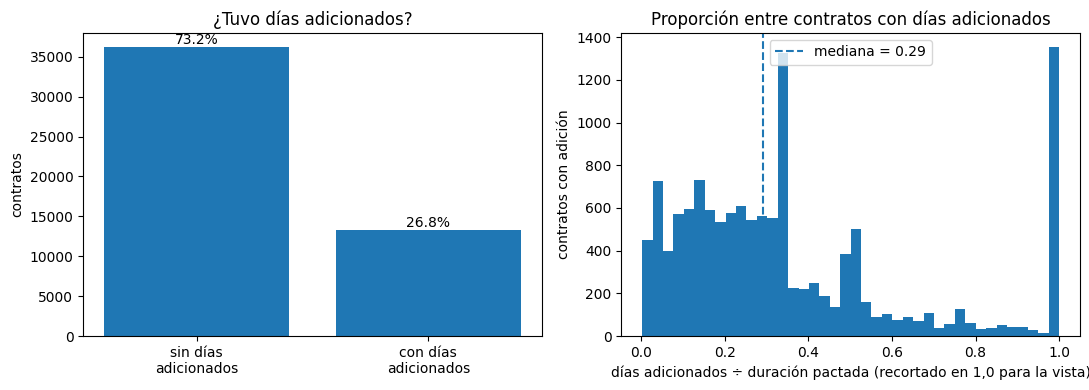

In [15]:
# E1 — distribución de la proporción de días adicionados
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

conteo = df_analisis["tuvo_dias_adicionados"].map({False: "sin días\nadicionados", True: "con días\nadicionados"}).value_counts()
ax[0].bar(conteo.index, conteo.values)
for i, v_ in enumerate(conteo.values):
    ax[0].text(i, v_, f"{v_ / len(df_analisis):.1%}", ha="center", va="bottom")
ax[0].set_ylabel("contratos")
ax[0].set_title("¿Tuvo días adicionados?")

ax[1].hist(prop_pos.clip(upper=1.0), bins=40)
ax[1].axvline(prop_pos.median(), linestyle="--", label=f"mediana = {prop_pos.median():.2f}")
ax[1].set_xlabel("días adicionados ÷ duración pactada (recortado en 1,0 para la vista)")
ax[1].set_ylabel("contratos con adición")
ax[1].set_title("Proporción entre contratos con días adicionados")
ax[1].legend(loc="upper center")
plt.tight_layout()
plt.show()

## Evidencia 2 · Valor inicial del contrato

**E2.** La frecuencia de días adicionados sube de forma sostenida con el valor inicial del contrato.

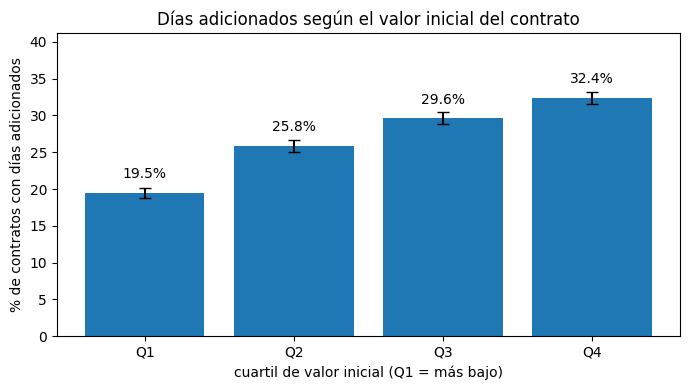

[0.19461077844311378, 0.2581323838808869, 0.2958895259630138, 0.3238465904483905] 12.92358120052767 0.1126894047387798 0.10136168537425268 0.5960617065440936


In [16]:
# E2 — tasa por cuartil de valor inicial, con IC 95 %
g = tablas["valor_del_contrato"]
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(g.index.astype(str), g["tasa"] * 100, yerr=[(g["tasa"] - g["ic95_inf"]) * 100, (g["ic95_sup"] - g["tasa"]) * 100], capsize=4)
for i, t in enumerate(g["tasa"]):
    ax.text(i, t * 100 + 2, f"{t:.1%}", ha="center")
ax.set_ylabel("% de contratos con días adicionados")
ax.set_xlabel("cuartil de valor inicial (Q1 = más bajo)")
ax.set_title("Días adicionados según el valor inicial del contrato")
ax.set_ylim(0, max(g["ic95_sup"]) * 100 + 8)
plt.tight_layout()
plt.show()

R["e2_q"] = [float(x) for x in g["tasa"]]
R["e2_brecha_pp"] = float((g["tasa"].iloc[-1] - g["tasa"].iloc[0]) * 100)
R["e2_ratio"] = float(g["tasa"].iloc[-1] / g["tasa"].iloc[0])
R["e2_rho"] = float(spearmanr(df_analisis["valor_del_contrato"], df_analisis[y].astype(int))[0])
R["e2_rho_prop"] = float(spearmanr(df_analisis["valor_del_contrato"], df_analisis["prop_dias_adicionados"])[0])
R["e2_q1_max"] = float(df_analisis.loc[df_analisis["cuartil_valor"] == "Q1", "valor_del_contrato"].max())
R["e2_q4_min"] = float(df_analisis.loc[df_analisis["cuartil_valor"] == "Q4", "valor_del_contrato"].min())
R["e2_rho_valor_duracion"] = float(spearmanr(df_analisis["valor_del_contrato"], df_analisis["duracion_pactada_valida"])[0])
print(R["e2_q"], R["e2_brecha_pp"], R["e2_rho"], R["e2_rho_prop"], R["e2_rho_valor_duracion"])

## Evidencia 3 · Sector y modalidad

**E3.** Los días adicionados se concentran en el sector Salud y en la contratación de régimen especial, que en este recorte se solapan.

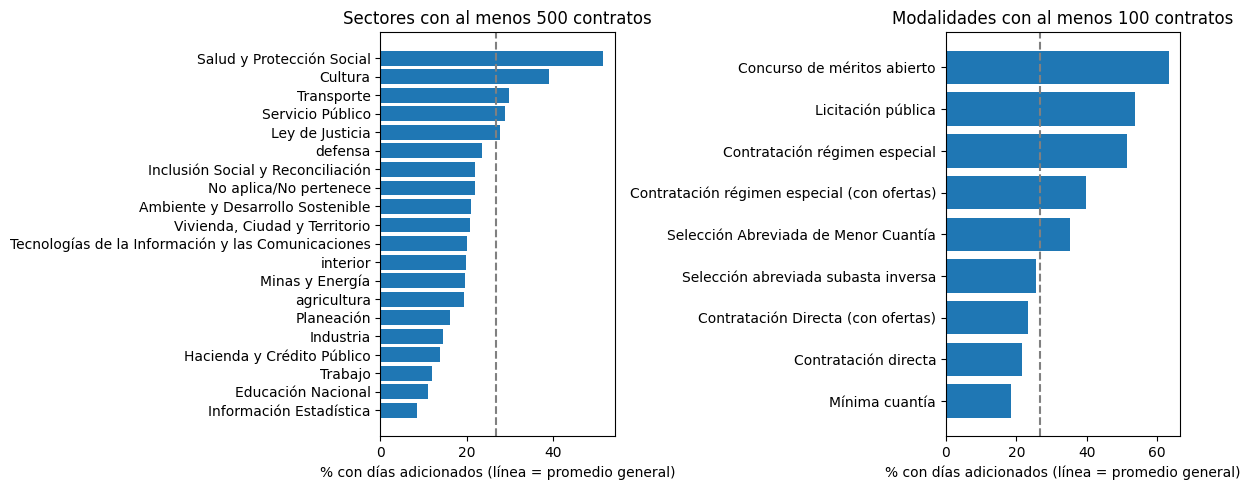

In [17]:
# E3 — sector y modalidad
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

s = tablas["sector"]; s = s[s["n"] >= 500].sort_values("tasa")
ax[0].barh(s.index, s["tasa"] * 100)
ax[0].axvline(R["e1_tasa"] * 100, linestyle="--", color="gray")
ax[0].set_xlabel("% con días adicionados (línea = promedio general)")
ax[0].set_title("Sectores con al menos 500 contratos")

mo = tablas["modalidad_de_contratacion"]; mo = mo[mo["n"] >= MIN_N].sort_values("tasa")
ax[1].barh(mo.index, mo["tasa"] * 100)
ax[1].axvline(R["e1_tasa"] * 100, linestyle="--", color="gray")
ax[1].set_xlabel("% con días adicionados (línea = promedio general)")
ax[1].set_title("Modalidades con al menos 100 contratos")
plt.tight_layout()
plt.show()

## Tablero de evidencia de la primera semana

La conclusión se refiere a **asociación** y a **días adicionados** (ampliaciones de tiempo). No es una predicción ni evidencia causal, y no mide adiciones presupuestales.

### E1
**Hallazgo:** Algo más de uno de cada cuatro contratos del recorte registra días adicionados; la mayoría (73,2 %) no registra ninguno y, entre los que sí, la ampliación mediana equivale a cerca de un tercio de la duración pactada y en casi uno de cada diez la supera.
**Cifra:** 26,8 % de 49.432 contratos con días adicionados; mediana de la proporción entre ellos = 0,29 (mediana de 46 días); percentil 90 = 1,00; 1.295 contratos (9,8 % de los que tienen adición) superan el 100 %.
**Visualización o salida:** gráfico E1 (barras + histograma) y tabla `resumen_prop`.
**Hipótesis explicativa:** las prórrogas de contratos de prestación de servicios son una práctica habitual para cubrir la vigencia; la proporción alta en contratos muy cortos es en parte aritmética.
**Duda pendiente:** no se puede medir el valor adicionado; falta saber si las prórrogas vinieron acompañadas de adiciones en dinero.

### E2
**Hallazgo:** Cuanto mayor es el valor inicial del contrato, mayor es la frecuencia de días adicionados.
**Cifra:** 19,5 % en el cuartil de menor valor (hasta 19,0 millones) frente a 32,4 % en el de mayor valor (desde 60,2 millones): brecha de 12,9 pp; ρ de Spearman = 0,11.
**Visualización o salida:** gráfico E2 y tabla por cuartil de valor.
**Hipótesis explicativa:** los contratos más grandes son más complejos y difíciles de dimensionar con exactitud al firmar, y sus supervisores tienen más razones para ampliarlos.
**Duda pendiente:** el valor y la duración pactada están relacionados (ρ = 0,60); falta ver si el valor tiene efecto propio o solo refleja modalidad, sector o duración.

### E3
**Hallazgo:** Los días adicionados se concentran en el sector Salud y Protección Social y en la modalidad de régimen especial, y ambos se solapan en el recorte.
**Cifra:** Salud: 51,7 % (n = 8.289) frente a 6,6 % en Presidencia de la República; régimen especial: 51,5 % (n = 7.921) frente a 21,6 % en contratación directa (n = 38.310); Salud dentro de régimen especial: 68,4 % (n = 5.345, 67 % de todo el régimen especial); el resto de contratos (n = 44.087) tiene 21,8 %. Las modalidades competitivas de mayor cuantía tienen tasas igual o más altas pero muy pocos contratos: concurso de méritos 63,3 % (n = 150) y licitación pública 53,6 % (n = 151).
**Visualización o salida:** gráfico E3 y tablas por sector y modalidad.
**Hipótesis explicativa:** el régimen contractual propio de las entidades de salud permite adicionar y prorrogar los contratos de apoyo a la gestión de forma recurrente (así lo indican las descripciones de algunas modificaciones de la tabla de adiciones, por ejemplo las de una subred de salud).
**Duda pendiente:** ¿la asociación es del sector, de la modalidad o de la práctica de unas pocas entidades? Falta comparar entidades dentro del sector.

### Checkpoint GitHub — Semana 7

- [x] el notebook ejecuta desde el inicio sin errores;
- [x] los datos utilizados están en `data/` (recorte y adiciones);
- [x] se justificaron tres decisiones de preparación;
- [x] E1, E2 y E3 tienen evidencia;
- [ ] el equipo realizó un commit descriptivo (*lo hace el equipo*).

**Release sugerida:** `v0.1-evidence`

# Segunda semana: poner a prueba la conclusión

**Objeción de trabajo:** las diferencias observadas pueden deberse a que ciertos tipos de contrato o modalidades son, al mismo tiempo, más costosos y más propensos a recibir adiciones.

1. **¿Qué parte de la conclusión inicial pone en duda?** El hallazgo E2: que el valor inicial esté asociado con los días adicionados.
2. **¿Qué tercera variable podría explicar parte de la asociación?** La modalidad (régimen especial, muy adicionada y de valor bajo o medio), el sector Salud y la duración pactada, que se relaciona con el valor.
3. **¿Qué comparación ayuda a comprobarlo?** Comparar la frecuencia de adición por cuartil de valor *dentro* de cada modalidad y de cada cuartil de duración, y estimar un modelo logístico que controle por todas las características candidatas a la vez.

In [18]:
# Frecuencia de días adicionados por cuartil de valor, dentro de cada modalidad y de cada cuartil de duración
principales = ["Contratación directa", "Contratación régimen especial", "Mínima cuantía"]
df_analisis["modalidad_g"] = df_analisis["modalidad_de_contratacion"].where(
    df_analisis["modalidad_de_contratacion"].isin(principales), "otras modalidades"
)

por_modalidad = pd.crosstab(df_analisis["modalidad_g"], df_analisis["cuartil_valor"], values=df_analisis[y], aggfunc="mean") * 100
n_modalidad = pd.crosstab(df_analisis["modalidad_g"], df_analisis["cuartil_valor"])
print("% con días adicionados por modalidad y cuartil de valor")
display(por_modalidad.round(1))
print("Número de contratos en cada celda")
display(n_modalidad)

por_duracion = pd.crosstab(df_analisis["cuartil_duracion"], df_analisis["cuartil_valor"], values=df_analisis[y], aggfunc="mean") * 100
print("% con días adicionados por cuartil de duración pactada y cuartil de valor")
display(por_duracion.round(1))

R["s_directa_q1"] = float(por_modalidad.loc["Contratación directa", "Q1"]) / 100
R["s_directa_q4"] = float(por_modalidad.loc["Contratación directa", "Q4"]) / 100
R["s_minima_q1"] = float(por_modalidad.loc["Mínima cuantía", "Q1"]) / 100
R["s_minima_q4"] = float(por_modalidad.loc["Mínima cuantía", "Q4"]) / 100
R["s_regesp_q1"] = float(por_modalidad.loc["Contratación régimen especial", "Q1"]) / 100
R["s_regesp_q2"] = float(por_modalidad.loc["Contratación régimen especial", "Q2"]) / 100
R["s_regesp_q4"] = float(por_modalidad.loc["Contratación régimen especial", "Q4"]) / 100
R["s_dur_q1_q4"] = [(float(por_duracion.loc[d, "Q1"]) / 100, float(por_duracion.loc[d, "Q4"]) / 100) for d in ["D1", "D2", "D3", "D4"]]

% con días adicionados por modalidad y cuartil de valor


cuartil_valor,Q1,Q2,Q3,Q4
modalidad_g,,,,
Contratación directa,11.200,19.900,25.300,29.300
Contratación régimen especial,45.500,59.900,60.500,44.100
Mínima cuantía,12.500,16.100,21.300,27.400
otras modalidades,14.800,14.800,18.500,39.200


Número de contratos en cada celda


cuartil_valor,Q1,Q2,Q3,Q4
modalidad_g,,,,
Contratación directa,8765,10176,10506,8863
Contratación régimen especial,2946,1867,1547,1561
Mínima cuantía,512,254,249,328
otras modalidades,135,61,81,1581


% con días adicionados por cuartil de duración pactada y cuartil de valor


cuartil_valor,Q1,Q2,Q3,Q4
cuartil_duracion,,,,
D1,19.300,31.300,54.500,40.400
D2,19.400,19.800,22.300,35.700
D3,19.900,26.900,28.900,30.300
D4,25.700,36.700,30.200,31.000


In [19]:
# Modelo logístico: ¿el valor inicial mantiene su asociación al controlar por las otras características?
# Requiere statsmodels (pip install statsmodels), que el notebook base ya usaba en la sección de potencia.
import statsmodels.formula.api as smf

d = df_analisis.copy()
d["y"] = d[y].astype(int)
d["log_valor"] = np.log(d["valor_del_contrato"])
d["log_duracion"] = np.log(d["duracion_pactada_valida"])
for col in ["log_valor", "log_duracion"]:
    d[col + "_z"] = (d[col] - d[col].mean()) / d[col].std()

top_tipo = d["tipo_de_contrato"].value_counts().index[:3]
top_sector = d["sector"].value_counts().index[:8]
d["tipo_g"] = d["tipo_de_contrato"].where(d["tipo_de_contrato"].isin(top_tipo), "otros tipos")
d["sector_g"] = d["sector"].where(d["sector"].isin(top_sector), "otros sectores")
d["mes_c"] = d["mes_firma"].astype(int).astype(str)
d["anio_c"] = d["anio_firma"].astype(int).astype(str)

formulas = {
    "M0: solo valor": "y ~ log_valor_z",
    "M1: valor + duración": "y ~ log_valor_z + log_duracion_z",
    "M2: + modalidad, tipo, sector, año y mes": "y ~ log_valor_z + log_duracion_z + C(modalidad_g) + C(tipo_g) + C(sector_g) + C(anio_c) + C(mes_c)",
}

filas = []
for nombre, f in formulas.items():
    ajuste = smf.logit(f, d).fit(disp=0)
    ic = np.exp(ajuste.conf_int())
    for var in ["log_valor_z", "log_duracion_z"]:
        if var in ajuste.params.index:
            filas.append({
                "modelo": nombre,
                "variable (por 1 desv. est. del logaritmo)": var.replace("_z", ""),
                "razón de momios": float(np.exp(ajuste.params[var])),
                "IC95 inf": float(ic.loc[var, 0]),
                "IC95 sup": float(ic.loc[var, 1]),
            })
    if nombre.startswith("M2"):
        R["m2_n"] = int(ajuste.nobs)
        R["m2_pseudo_r2"] = float(ajuste.prsquared)

modelos = pd.DataFrame(filas)
display(modelos)
R["modelos"] = modelos.to_dict("records")

,modelo,variable (por 1 desv. est. del logaritmo),razón de momios,IC95 inf,IC95 sup
0,M0: solo valor,log_valor,1.313,1.286,1.340
1,M1: valor + duración,log_valor,1.374,1.343,1.406
2,M1: valor + duración,log_duracion,0.902,0.882,0.922
3,"M2: + modalidad, tipo, sector, año y mes",log_valor,1.354,1.313,1.396
4,"M2: + modalidad, tipo, sector, año y mes",log_duracion,1.397,1.354,1.442


In [20]:
# Sensibilidad: ¿cambia la conclusión con otras decisiones razonables?
# a) desenlaces alternativos, por cuartil de valor
alternativos = df_analisis.groupby("cuartil_valor", observed=True).agg(
    dias_adicionados=(y, "mean"),
    estado_modificado=("es_modificado", "mean"),
    registro_en_tabla_adiciones=("tuvo_registro_adicion", "mean"),
) * 100
alternativos["dias_o_modificado"] = df_analisis.assign(o=df_analisis[y] | df_analisis["es_modificado"]).groupby("cuartil_valor", observed=True)["o"].mean() * 100
print("% de contratos por cuartil de valor, según el desenlace")
display(alternativos.round(2))
R["sens_modificado_q1"] = float(alternativos.loc["Q1", "estado_modificado"]) / 100
R["sens_modificado_q4"] = float(alternativos.loc["Q4", "estado_modificado"]) / 100
R["sens_registro_q1"] = float(alternativos.loc["Q1", "registro_en_tabla_adiciones"]) / 100
R["sens_registro_q4"] = float(alternativos.loc["Q4", "registro_en_tabla_adiciones"]) / 100

# b) sin el 1 % de mayor valor
p99 = df_analisis["valor_del_contrato"].quantile(0.99)
sin_top = df_analisis[df_analisis["valor_del_contrato"] <= p99]
R["sens_rho_sin_top1"] = float(spearmanr(sin_top["valor_del_contrato"], sin_top[y].astype(int))[0])
print(f"ρ valor ↔ días adicionados sin el 1 % superior: {R['sens_rho_sin_top1']:.3f} (con todos: {R['e2_rho']:.3f})")

# c) por año de firma
por_anio = pd.crosstab(df_analisis["cuartil_valor"], df_analisis["anio_firma"], values=df_analisis[y], aggfunc="mean") * 100
print("% con días adicionados por cuartil de valor y año de firma")
display(por_anio.round(1))
R["sens_anio"] = {int(c): [float(x) / 100 for x in por_anio[c]] for c in por_anio.columns}

# d) duración por fechas (contaminada por las prórrogas) en el modelo completo
d2 = d[(d["duracion_dias"] > 0) & (d["duracion_dias"] <= DUR_MAX)].copy()
d2["log_duracion_fechas_z"] = (np.log(d2["duracion_dias"]) - np.log(d2["duracion_dias"]).mean()) / np.log(d2["duracion_dias"]).std()
f_fechas = "y ~ log_valor_z + log_duracion_fechas_z + C(modalidad_g) + C(tipo_g) + C(sector_g) + C(anio_c) + C(mes_c)"
aj = smf.logit(f_fechas, d2).fit(disp=0)
R["sens_or_valor_con_duracion_fechas"] = float(np.exp(aj.params["log_valor_z"]))
R["sens_or_duracion_fechas"] = float(np.exp(aj.params["log_duracion_fechas_z"]))
print(f"Con duración por fechas: OR valor = {R['sens_or_valor_con_duracion_fechas']:.2f}, OR duración = {R['sens_or_duracion_fechas']:.2f}")

% de contratos por cuartil de valor, según el desenlace


,dias_adicionados,estado_modificado,registro_en_tabla_adiciones,dias_o_modificado
cuartil_valor,,,,
Q1,19.460,24.350,0.210,25.440
Q2,25.810,29.660,0.240,31.690
Q3,29.590,34.280,0.200,37.090
Q4,32.380,37.100,0.270,40.210


ρ valor ↔ días adicionados sin el 1 % superior: 0.106 (con todos: 0.113)
% con días adicionados por cuartil de valor y año de firma


anio_firma,2024,2025
cuartil_valor,,
Q1,18.100,21.500
Q2,20.900,31.100
Q3,22.300,35.300
Q4,26.800,36.500


Con duración por fechas: OR valor = 0.89, OR duración = 3.47


### Deténgase y revise — respuesta a la objeción

1. **¿La frecuencia de adiciones cambia entre grupos de valor?** Sí: de 19,5 % en Q1 a 32,4 % en Q4 (E2).
2. **¿La modalidad modifica la comparación?** Sí, pero no la elimina. Dentro de contratación directa la tasa sube de 11,2 % a 29,3 %, y en mínima cuantía de 12,5 % a 27,4 %. En régimen especial el patrón **no es monótono**: 45,5 % en Q1, 59,9 % en Q2 y 44,1 % en Q4. Ahí la tasa base ya es alta y el valor aporta poco.
3. **¿El hallazgo inicial se mantiene, se debilita o cambia?** Se **mantiene**: la objeción no lo explica. En el modelo logístico, un aumento de una desviación estándar del logaritmo del valor tiene razón de momios 1,31 sola y 1,35 tras controlar por duración, modalidad, tipo, sector, año y mes (IC95: 1,31–1,40); es decir, no se debilita al controlar. Lo que sí cambia es la lectura de la modalidad: dentro de régimen especial el valor casi no discrimina (patrón no monótono).
4. **Explicación alternativa que apareció:** el sector Salud con régimen especial (E3) concentra contratos de bajo valor con muchas adiciones, y el año de firma también pesa: la tasa es 21,6 % en 2024 y 31,9 % en 2025, y los contratos de octubre a diciembre tienen tasas más altas (mes con mayor tasa: 12, 36,0 %; menor: 9, 20,9 %).
5. **Conclusión que todavía sería excesiva:** decir que el valor *causa* la adición, que el patrón vale para todo SECOP II o que predice adiciones **presupuestales**. Con estos datos solo se puede hablar de días adicionados, en un recorte de 50.000 contratos de Bogotá cuyo criterio de selección no está documentado.

**Sensibilidad (ver celda anterior).** Con el estado `Modificado` como desenlace alternativo, la tasa pasa de 24,3 % (Q1) a 37,1 % (Q4); el registro en la tabla de adiciones no discrimina (0,21 % vs. 0,27 %) porque casi no tiene casos. El gradiente de valor aparece en ambos años de firma (2024: 18,1 % → 26,8 %; 2025: 21,5 % → 36,5 %). Quitar el 1 % de mayor valor deja ρ = 0,106 (con todos: 0,113). Por último, con la duración *por fechas* en el modelo completo, la razón de momios de la duración sube a 3,47 (contra 1,40 con la pactada) y la del valor cae a 0,89, es decir, **deja de ser positiva**: medir mal la duración habría cambiado la conclusión sobre el valor, que es el efecto mecánico descrito en la decisión 2.

## Asociación no significa causalidad

**1. ¿Qué variable podría estar influyendo en la relación observada?** La *complejidad del objeto contractual* (obra, interventoría, servicios especializados), no medida aquí, que eleva a la vez el valor inicial y la probabilidad de necesitar más tiempo. También la *práctica de cada entidad* (es posible que unas pocas entidades de salud concentren buena parte de las adiciones; este recorte no lo verifica) y el *año de firma* (ver E3 y sensibilidad).

**2. ¿Por qué modificaría la interpretación?** Si la complejidad determina a la vez el valor y la adición, el valor seguiría asociado a la adición aunque cambiar el valor de un contrato no cambiara su probabilidad de ser ampliado. Si la práctica de la entidad domina, el «riesgo» estaría en la entidad y no en las características del contrato.

**3. ¿Qué información adicional sería necesaria?** Identificador de entidad como efecto fijo o análisis dentro de cada entidad; el objeto contractual clasificado (código UNSPSC o texto); el valor adicionado real y su fecha; la fecha de cada prórroga para separar duración pactada de duración final; y la razón registrada de cada modificación.

## Pensar un experimento antes de hablar de causalidad

1. **Grupos A y B.** Contratos de características similares (mismo objeto, entidad y duración) en los que se asigna un presupuesto inicial *ajustado* (A) o *holgado* (B).
2. **Resultado.** Proporción de contratos con adición y proporción del valor adicionado sobre el valor inicial a los 6 y 12 meses, junto con los días adicionados.
3. **¿Viable asignar al azar?** No. Asignar presupuestos distintos a contratos reales es inviable en términos legales, éticos y operativos (principios de planeación y de selección objetiva).
4. **Diseño observacional alternativo.** Comparar contratos de la **misma entidad** y del **mismo objeto contractual** que difieren en el valor inicial (efectos fijos de entidad y de categoría UNSPSC), o aprovechar un umbral normativo que cambie el valor de forma abrupta (por ejemplo, los topes de mínima cuantía o de selección abreviada) en un diseño de regresión discontinua. **Variable adicional a controlar:** la complejidad del objeto contractual y la identidad de la entidad.

### Una aproximación al concepto de potencia

Se adapta el cálculo del notebook base a **proporciones**, porque el desenlace es binario (con o sin días adicionados). Se pregunta cuántos contratos por grupo se necesitarían para detectar con 80 % de potencia una brecha de 10 puntos porcentuales —el umbral del criterio previo— entre los grupos Q1 y Q4 de valor, usando la aproximación normal con la transformación arcoseno de Cohen.

In [21]:
alpha = 0.05
target_power = 0.80
p_base = float(tablas["valor_del_contrato"]["tasa"].iloc[0])       # tasa observada en Q1
p_relevante = p_base + UMBRAL_BRECHA_PP / 100                       # tasa que representaría la brecha mínima relevante

h = 2 * math.asin(math.sqrt(p_relevante)) - 2 * math.asin(math.sqrt(p_base))   # tamaño del efecto (h de Cohen)

normal = NormalDist()
z_alpha = normal.inv_cdf(1 - alpha / 2)
z_power = normal.inv_cdf(target_power)
n_per_group = math.ceil(2 * ((z_alpha + z_power) / h) ** 2)

R["pot_h"] = float(h)
R["pot_n"] = int(n_per_group)
R["pot_n_disp"] = int(tablas["valor_del_contrato"]["n"].min())

pd.Series({
    "alpha": alpha,
    "potencia_objetivo": target_power,
    "tasa_base (Q1)": p_base,
    "tasa_relevante (Q1 + 10 pp)": p_relevante,
    "tamaño_de_efecto_h": h,
    "n_aproximado_por_grupo": n_per_group,
    "n_disponible_por_cuartil": R["pot_n_disp"],
})

alpha                              0.050
potencia_objetivo                  0.800
tasa_base (Q1)                     0.195
tasa_relevante (Q1 + 10 pp)        0.295
tamaño_de_efecto_h                 0.234
n_aproximado_por_grupo           288.000
n_disponible_por_cuartil      12,333.000
dtype: float64

**Lectura.** Detectar una brecha de 10 pp desde una base de 19,5 % requiere alrededor de 288 contratos por grupo; cada cuartil tiene 12.333. El tamaño de la muestra **no es el problema**: hay potencia de sobra para detectar la brecha de valor y también otras mucho menores, por lo que la significancia estadística no aporta información y lo que importa es la magnitud. Tener muchas filas tampoco corrige un sesgo de selección (recorte truncado de criterio desconocido) ni una variable de confusión no medida.

### Antes de terminar

1. Si la diferencia de interés fuera más pequeña, se necesitarían **más** observaciones (el tamaño necesario crece con el inverso del cuadrado de la diferencia).
2. Muchas filas reducen el error aleatorio, no el sesgo: un recorte no representativo o una variable omitida producen el mismo error con 50 filas o con 50 millones.
3. La limitación más importante tras completar la segunda semana es que **no se pudo medir el valor adicionado**: la conclusión describe ampliaciones de tiempo y no adiciones presupuestales, que es lo que pide el brief.

## Evidence Card — veredicto final

**Afirmación investigada:**
> Existen características observables al momento de la firma que se asocian posteriormente con adiciones al contrato.

**Veredicto**
- [ ] Respaldada
- [x] **Parcialmente respaldada**
- [ ] No respaldada

**Por qué parcialmente.** Hay asociaciones que superan el umbral de relevancia fijado de antemano y sobreviven a la objeción (valor inicial, sector, modalidad), pero la afirmación se probó solo para **días adicionados**, no para adiciones presupuestales; la duración pactada, en cambio, discrimina poco en bruto y su efecto depende del modelo.

**Tres evidencias principales**
1. **E2 — valor inicial:** 19,5 % de contratos con días adicionados en el cuartil de menor valor frente a 32,4 % en el de mayor valor (12,9 pp); se mantiene tras controlar por modalidad, tipo, sector, duración, año y mes.
2. **E3 — sector y modalidad:** 51,7 % en Salud y 51,5 % en régimen especial, frente a 26,8 % en el conjunto; el cruce Salud × régimen especial llega a 68,4 %.
3. **Decisión 2 — duración:** con la duración calculada por fechas parecería el predictor más fuerte (ρ = 0,28), pero en buena parte es un efecto mecánico; con la duración pactada la asociación cruda es débil y no monótona (ρ = 0,05; brecha Q4−Q1 de 4,8 pp) y su razón de momios cambia de 0,90 a 1,40 según los controles: no es una característica estable.

**Visualización central:** gráfico E2 (frecuencia de días adicionados por cuartil de valor inicial, con intervalos de confianza).

**Limitación principal:** el brief pide la proporción del *valor* adicionado sobre el valor inicial, y la tabla de adiciones entregada no contiene montos; además solo empata con 0,23 % del recorte. La conclusión se restringe a días adicionados en un recorte truncado (50.000 de 567.075 contratos), con criterio de selección desconocido y sin variable de complejidad ni de entidad.

**Recomendación para el cliente:** al revisar contratos nuevos de Bogotá, dar mayor atención a los de **mayor valor inicial** y a los del **sector Salud bajo régimen especial** como candidatos a ampliaciones de plazo, sin tratar la característica como causa ni como predicción individual; y pedir a la fuente los montos de adición para probar la afirmación completa.

## Uso de inteligencia artificial

**Herramienta utilizada:** Claude (Anthropic).

**Actividad en la que se utilizó:** exploración de los archivos, escritura y depuración del código de cruce, comparación y modelo logístico, y redacción de borradores de las decisiones, el tablero y el veredicto.

**Resultado que fue verificado y forma de verificación:** *[Confirmar por el equipo antes de entregar]* Reejecución completa del notebook (`Run All`) y comparación de las cifras del tablero con las salidas; comprobación manual del cruce con `id_contrato` sobre una muestra de contratos y de la duración pactada leída del texto; revisión de que el texto del veredicto no afirma más de lo que muestran las tablas.

**Una decisión del equipo que NO se delegó a IA:** *[Confirmar por el equipo antes de entregar]* la aceptación de los umbrales del criterio previo y del veredicto final («parcialmente respaldada»), y la decisión de consultar al profesor por la ausencia de montos en la tabla de adiciones.

## Cierre en GitHub

Antes de crear la entrega final:

- [ ] `Run All` termina sin errores;
- [ ] los datos utilizados están en `data/`;
- [ ] las decisiones de preparación están justificadas;
- [ ] E1, E2 y E3 son rastreables;
- [ ] la objeción fue respondida;
- [ ] el veredicto reconoce limitaciones;
- [ ] la declaración de IA está completa y confirmada por el equipo;
- [ ] el historial de commits muestra el proceso.

**Release Semana 7:** `v0.1-evidence`  
**Release Semana 8:** `v1.0-verdict`